# <center>Assessment CLO-3: Tugas Pemrograman Learning</center>

<b>Topik</b>
[Klasifikasi pada Ecoli menggunakan k-Nearest Neighbors]

<b>Kelompok: </b>

Anggota:
1. Sherly Angelina - 1301223370
2. Nur Afny Putri Pratiwi IS - 1301223256
3. M.Salman Razak Alfarisi - 1301220487

#### Pendahuluan
 #### Pendahuluan
Dataset yang digunakan adalah dataset Ecoli, yang digunakan untuk melakukan klasifikasi jenis lokasi subcellular protein pada bakteri Ecoli. Dataset ini terdiri dari dua bagian utama: data fitur(dataset_feature) dan data target(dataset_target).

Data fitur berisi informasi terkait dengan karakteristik fisik dan kimia dari sekuen protein, yang dapat digunakan untuk memprediksi lokasi subcellular protein. Fitur-fitur ini adalah sebagai berikut:
1.   mcg: Metode McGeoch untuk pengenalan urutan sinyal.
2.   gvh: Metode von Heijne untuk pengenalan urutan sinyal.
1.   lip: Skor konsensus urutan sinyal Lipoprotein von Heijne.
2.   chg: Keberadaan muatan pada N-terminus dari lipoprotein yang diprediksi. Atribut biner
1.   aac: Skor dari analisis diskriminan dari isi asam amino dari protein membran luar dan periplasmik.
2.   alm1: Skor dari program prediksi daerah melintang membran ALOM.
1.   alm2: Skor dari program ALOM setelah mengeluarkan daerah sinyal yang dapat dipotong dari urutan.

Data target berisi kelas-kelas lokasi subcellular protein yang akan diprediksi. Kelas-kelas ini adalah sebagai berikut.
1.   cp: Sitoplasma.
2.   im: Membran bagian dalam tanpa urutan sinyal.
1. pp: periplasma
1.   imU: Membran bagian dalam, urutan sinyal tidak dapat diubah.
2.   om: Membran luar.
1.   omL: Lipoprotein membran luar.
2.   imL: Lipoprotein membran dalam.
1.   imS: Membran bagian dalam, urutan sinyal yang dapat dibelah.

Masalah yang akan diselesaikan adalah melakukan klasifikasi jenis lokasi subcellular protein pada bakteri Ecoli berdasarkan fitur-fitur yang diberikan, dengan menggunakan model klasifikasi yang sesuai. Tujuan utamanya adalah untuk memprediksi letak/lokasi subcelullar protein dari fitur yang diberikan dengan akurasi sebaik mungkin.

Untuk menyelesaikan masalah klasifikasi akan dilakukan pra-pemrosesan data sebelum dilakukan pelatihan model dengan algoritma yang telah ditentukan. Langkah-langkah dalam pra-pemrosesan data pada percobaan ini dapat dirincikan sebagai berikut.

1.   Cek info dari data. Tahapan ini dilakukan untuk mengetahui informasi dari dataset, seperti kolom, jumlah non-null, dan tipe data.
2.   Cek nilai yang hilang atau missing value. Tahapan ini dilakukan untuk mengetahui banyaknya nilai yang hilang pada sebuah dataframe. Hal ini perlu dilakukan karena nilai yang hilang dapat berpengaruh pada performa model.
1.   Cek persebaran data target. Tahapan ini dilakukan untuk mengetahui proporsi setiap kelas dari data target.
2. Encode data kategori. Tahapan ini dilakukan untuk mendapatkan korelasi terhadap fitur yang ada.
2.  Menggabungkan dataset_feature dengan dataset_target
3. Menampilkan visualisasi dataset feature untuk melihat persebaran data fitur.
1.   Bagi dataset atau split dataset. Tahapan ini dilakukan untuk membagi data menjadi data latih, data uji, dan data validasi. Pada percobaan ini dilakukan pembagian dataset dengan proporsi 80% data latih dan 20% data uji.
2.   Normalisasi data. Tahapan ini dilakukan agar data latih berada pada skala konsisten.
1.  Membandingkan hasil visualisasi persebaran data fitur, sebelum dan sesudah di normalisasi

Selain pra-pemrosesan data, pada tahap awal akan dilihat visualisasi dari data. Visualisasi pada percobaan ini dilakukan dengan membuat heatmap korelasi dan boxplot persebaran data fitur.



In [1]:
import pandas as pd # untuk buka data
import numpy as np # untuk replace data

In [2]:
pip install ucimlrepo

In [3]:
from ucimlrepo import fetch_ucirepo
# fetch dataset
ecoli = fetch_ucirepo(id=39)

# data (as pandas dataframes)
dataset_feature = ecoli.data.features
dataset_target = ecoli.data.targets

In [4]:
dataset_feature

,mcg,gvh,lip,chg,aac,alm1,alm2
0,0.49,0.29,0.48,0.5,0.56,0.24,0.35
1,0.07,0.40,0.48,0.5,0.54,0.35,0.44
2,0.56,0.40,0.48,0.5,0.49,0.37,0.46
3,0.59,0.49,0.48,0.5,0.52,0.45,0.36
4,0.23,0.32,0.48,0.5,0.55,0.25,0.35
...,...,...,...,...,...,...,...
331,0.74,0.56,0.48,0.5,0.47,0.68,0.30
332,0.71,0.57,0.48,0.5,0.48,0.35,0.32
333,0.61,0.60,0.48,0.5,0.44,0.39,0.38
334,0.59,0.61,0.48,0.5,0.42,0.42,0.37


In [5]:
dataset_target

,class
0,cp
1,cp
2,cp
3,cp
4,cp
...,...
331,pp
332,pp
333,pp
334,pp


###Data Preprocessing

In [6]:
# Cek Info Data
print("Info data fitur")
dataset_feature.info()

print("\nInfo data target")
dataset_target.info()

Info data fitur
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336 entries, 0 to 335
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   mcg     336 non-null    float64
 1   gvh     336 non-null    float64
 2   lip     336 non-null    float64
 3   chg     336 non-null    float64
 4   aac     336 non-null    float64
 5   alm1    336 non-null    float64
 6   alm2    336 non-null    float64
dtypes: float64(7)
memory usage: 18.5 KB

Info data target
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336 entries, 0 to 335
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   class   336 non-null    object
dtypes: object(1)
memory usage: 2.8+ KB


In [7]:
# Cek Missing Value
print("Missing Value data fitur")
print(dataset_feature.isnull().sum())

print("\nMissing Value data target")
print(dataset_target.isnull().sum())

Missing Value data fitur
mcg     0
gvh     0
lip     0
chg     0
aac     0
alm1    0
alm2    0
dtype: int64

Missing Value data target
class    0
dtype: int64


In [8]:
# Cek Persebaran Data Target
class_counts = dataset_target['class'].value_counts()
print("Jumlah sampel dalam setiap kelas:")
print(class_counts)

class_proportions = class_counts / class_counts.sum()
print("\nProporsi setiap kelas:")
print(class_proportions)

Jumlah sampel dalam setiap kelas:
class
cp     143
im      77
pp      52
imU     35
om      20
omL      5
imS      2
imL      2
Name: count, dtype: int64

Proporsi setiap kelas:
class
cp     0.425595
im     0.229167
pp     0.154762
imU    0.104167
om     0.059524
omL    0.014881
imS    0.005952
imL    0.005952
Name: count, dtype: float64


In [24]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
dataset_target['class']= le.fit_transform(dataset_target['class'])
dataset_target

# Menampilkan hasil transformasi sebagai array
transformed_array = dataset_target['class'].values
print("Hasil transformasi sebagai array:")
print(transformed_array)

Hasil transformasi sebagai array:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 3 3
 2 2 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 6 6 6 6 6 7 7 7 7 7 7 7 7 7 7 7 7
 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7 7
 7 7 7]


<ipython-input-24-b59140c082e8>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset_target['class']= le.fit_transform(dataset_target['class'])


In [10]:
dataset_ecoli = pd.concat([dataset_feature, dataset_target], axis=1)
dataset_ecoli

,mcg,gvh,lip,chg,aac,alm1,alm2,class
0,0.49,0.29,0.48,0.5,0.56,0.24,0.35,0
1,0.07,0.40,0.48,0.5,0.54,0.35,0.44,0
2,0.56,0.40,0.48,0.5,0.49,0.37,0.46,0
3,0.59,0.49,0.48,0.5,0.52,0.45,0.36,0
4,0.23,0.32,0.48,0.5,0.55,0.25,0.35,0
...,...,...,...,...,...,...,...,...
331,0.74,0.56,0.48,0.5,0.47,0.68,0.30,7
332,0.71,0.57,0.48,0.5,0.48,0.35,0.32,7
333,0.61,0.60,0.48,0.5,0.44,0.39,0.38,7
334,0.59,0.61,0.48,0.5,0.42,0.42,0.37,7


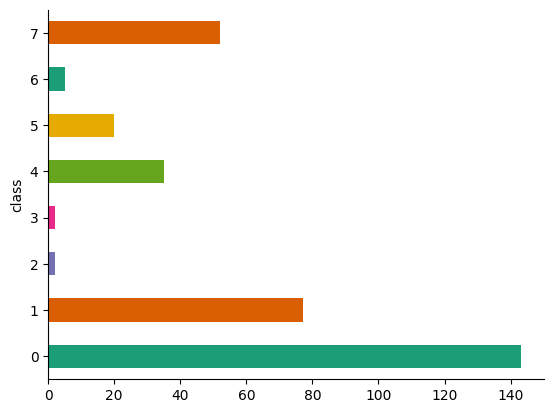

In [11]:
from matplotlib import pyplot as plt
import seaborn as sns
dataset_ecoli.groupby('class').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

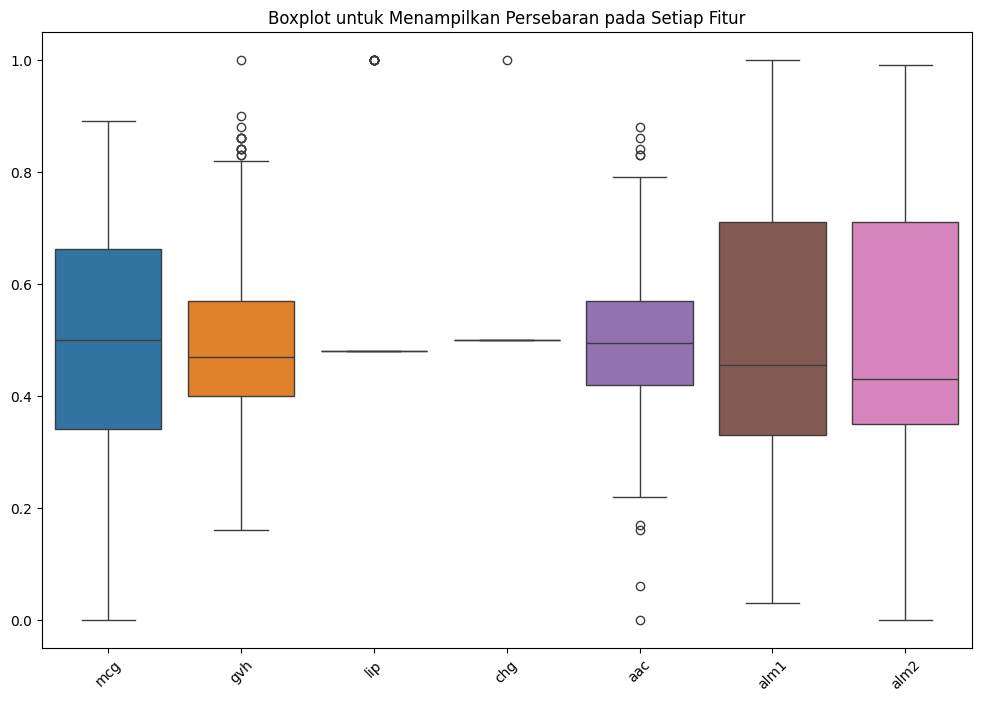

In [12]:
import  matplotlib.pyplot as plt # utk grafik
import seaborn as sns
# Visualisasi Boxplot antar fitur
plt.figure(figsize=(12, 8))
sns.boxplot(data=dataset_feature)
plt.title('Boxplot untuk Menampilkan Persebaran pada Setiap Fitur')
plt.xticks(rotation=45)
plt.show()

In [13]:
from sklearn.model_selection import train_test_split
# Pisahkan data
X = dataset_ecoli.drop(['lip', 'chg', 'class'], axis=1)
y = dataset_ecoli['class']

# Bagi menjadi data uji dan data test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
from sklearn.preprocessing import StandardScaler
# Normalisasi data dengan menggunakan StandarScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

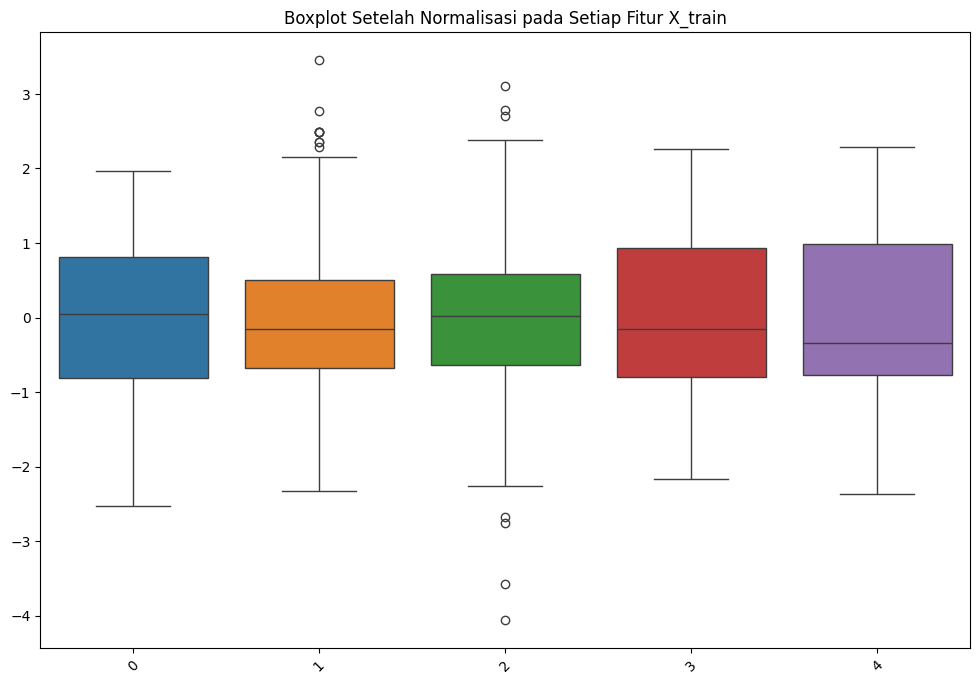

In [15]:
plt.figure(figsize=(12, 8))
sns.boxplot(data=X_train)
plt.title('Boxplot Setelah Normalisasi pada Setiap Fitur X_train')
plt.xticks(rotation=45)
plt.show()

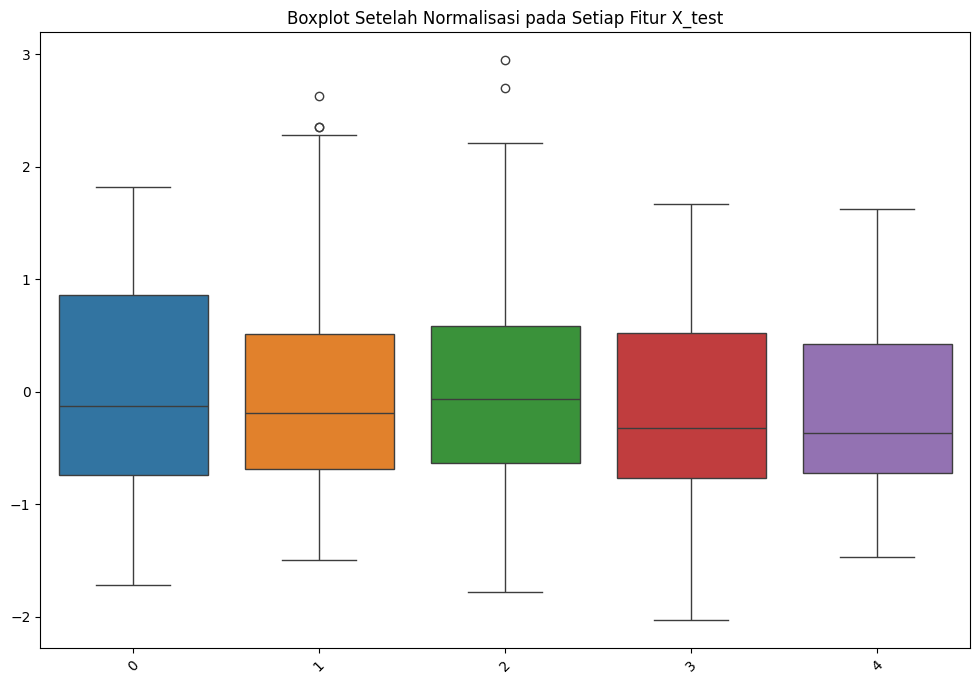

In [16]:
plt.figure(figsize=(12, 8))
sns.boxplot(data=X_test)
plt.title('Boxplot Setelah Normalisasi pada Setiap Fitur X_test')
plt.xticks(rotation=45)
plt.show()

(array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5]),
 [Text(0.5, 0, 'mcg'),
  Text(1.5, 0, 'gvh'),
  Text(2.5, 0, 'lip'),
  Text(3.5, 0, 'chg'),
  Text(4.5, 0, 'aac'),
  Text(5.5, 0, 'alm1'),
  Text(6.5, 0, 'alm2'),
  Text(7.5, 0, 'class')])

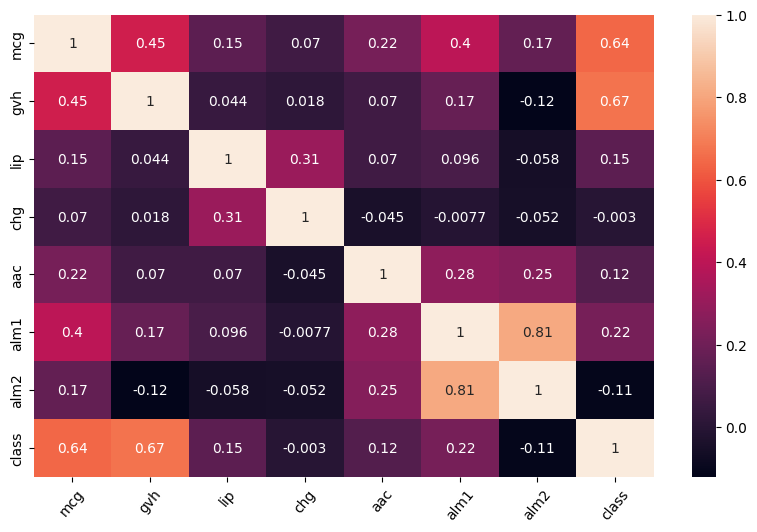

In [17]:
fig = plt.figure(figsize=(10, 6))
cor = dataset_ecoli.corr()
sns.heatmap(cor, annot=True)
plt.xticks(rotation=50)

#### Metode yang Digunakan
Pada percobaan learning ini, klasifikasi data ecoli menggunakan algoritma k-Nearest Neighbors (kNN). kNN merupakan sebuah algoritma dalam machine learning yang digunakan untuk klasifikasi dan regresi. Dalam kNN, prediksi dilakukan dengan membandingkan data yang akan diprediksi dengan sejumlah k data tetangga terdekat dalam ruang fitur. Nilai dari k adalah jumlah tetangga terdekat yang dipilih oleh pengguna.

Setting parameter pada percobaan ini meliputi nilai k dan distance. k merupakan jumlah tetangga terdekat yang ditentukan untuk melakukan prediksi dan distance merupakan metrik jarak untuk untuk mengukur jarak antara titik-titik dalam ruang fitur. Nilai default k yang ditentukan adalah 5, namun dalam proses selanjutnya akan ditentukan nilai k yang lain untuk mencari performa terbaik model. Distance pada percobaan ini menggunakan metrik euclidean distance sebagai pengukur jarak antara titik data uji dan setiap titik dalam data latih. Jarak euclidean ini kemudian digunakan untuk menentukan tetangga terdekat dan memprediksi label data uji.

Experiment Settings

In [18]:
# Fungsi untuk menentukan elemen yang paling umum dalam data
def most_common(elements):
    result_most_common = max(set(elements), key=elements.count) # Menghitung elemen yang paling sering muncul
    return result_most_common # Mengembalikan result_most_common

# Fungsi untuk menghitung jarak euclidean antara dua titik
def euclidean_distance(point1, point2):
    result_euclidean_distance = np.sqrt(np.sum((point1 - point2)**2, axis=1)) # Menghitung jarak Euclidean antara point1 dan setiap baris dalam point2
    return result_euclidean_distance # Mengembalikan result_euclidean_distance

# Class untuk mendefinisikan Klasifikasi KNN
class kNNClassifier:
    # Fungsi Konstruktor dengan parameter k dan metrik jarak
    def __init__(self, k=5, distance=euclidean_distance):
        self.k = k # jumlah tetangga terdekat yang digunakan
        self.distance = distance # metrik jarak yang digunakan

    # Fungsi untuk melatih model dengan data train
    def fit(self, X_train, y_train):
        self.X_train = X_train # Menyimpan data latih
        self.y_train = y_train # Menyimpan label data latih

    # Fungsi untuk memprediksi label data test
    def predict(self, X_test):
        neighbors = [] # Inisialisasi neighbors sebagai list untuk menyimpan tetangga terdekat
        for x in X_test:
            distances = self.distance(x, self.X_train)  # Menghitung jarak antara x dan setiap titik dalam data latih
            y_sorted = [y for _, y in sorted(zip(distances, self.y_train))]  # Mengurutkan label data latih berdasarkan jarak yang dihitung
            neighbors.append(y_sorted[:self.k]) # Menyimpan k tetangga terdekat
        return list(map(most_common, neighbors)) # Mengembalikan label yang paling umum di antara tetangga terdekat

    # Fungsi untuk mengevaluasi performa model berdasarkan data test
    def evaluate(self, X_test, y_test):
        y_pred = self.predict(X_test) # Memprediksi label untuk data uji
        accuracy = sum(y_pred == y_test) / len(y_test) # Inisialisasi accuracy sebagai perhitungan akurasi dengan membandingkan prediksi dengan label sebenarnya
        return accuracy # Mengembalikan nilai accuracy

Model Training

In [25]:
# Mencari k terbaik menggunakan holdout validation
accuracies = [] # List untuk menyimpan akurasi dari setiap nilai k yang diuji
ks = range(1, 15) # Rentang nilai k yang akan diuji, dari 1 hingga 14
best_score = 0.0 # Nilai awal untuk menyimpan akurasi terbaik yang ditemukan

# Iterasi melalui setiap nilai k yang diuji
for k in ks:
    kNN = kNNClassifier(k=k) # Inisialisasi objek kNNClassifier dengan nilai k tertentu
    kNN.fit(X_train, y_train) # Melatih model dengan data latih
    accuracy = kNN.evaluate(X_test, y_test) # Menghitung akurasi model dengan data uji
    accuracies.append(accuracy) # Menyimpan akurasi untuk nilai k tertentu

    if accuracy > best_score: # Pengondisian untuk memeriksa apakah akurasi yang baru ditemukan lebih baik dari yang sebelumnya terbaik
        best_score = accuracy # Update nilai akurasi terbaik
        best_k = k # Simpan nilai k yang menghasilkan akurasi terbaik

    print(f'k = {k}: Akurasi = {accuracy}') # Menampilkan akurasi untuk setiap nilai k

print(f'k terbaik: {best_k} dengan akurasi: {best_score}') # Mencetak nilai k terbaik beserta akurasinya setelah iterasi selesai

k = 1: Akurasi = 0.7941176470588235
k = 2: Akurasi = 0.8382352941176471
k = 3: Akurasi = 0.8676470588235294
k = 4: Akurasi = 0.8823529411764706
k = 5: Akurasi = 0.8676470588235294
k = 6: Akurasi = 0.9117647058823529
k = 7: Akurasi = 0.9117647058823529
k = 8: Akurasi = 0.9117647058823529
k = 9: Akurasi = 0.9117647058823529
k = 10: Akurasi = 0.9117647058823529
k = 11: Akurasi = 0.8970588235294118
k = 12: Akurasi = 0.8970588235294118
k = 13: Akurasi = 0.8970588235294118
k = 14: Akurasi = 0.8970588235294118
k terbaik: 6 dengan akurasi: 0.9117647058823529


Model Testing dan Evaluasi

In [20]:
# Mencetak prediksi berdasarkan k terbaik
classifier = kNNClassifier(k=6) # Membuat instance dari classifier
classifier.fit(X_train, y_train) # Melatih model
y_pred = classifier.predict(X_test) # Memprediksi data uji
y_pred # Mencetak hasil prediksi

[0,
 0,
 7,
 0,
 5,
 0,
 4,
 6,
 7,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 4,
 0,
 0,
 7,
 0,
 0,
 0,
 5,
 1,
 0,
 0,
 5,
 7,
 0,
 0,
 7,
 1,
 5,
 0,
 7,
 0,
 0,
 1,
 4,
 0,
 5,
 7,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 5,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 7,
 7,
 7,
 0,
 1]

In [21]:
#evaluasi model
from collections import Counter

# Fungsi untuk membuat classification report
def classification_report(y_true, y_pred, labels):
    report = {}  # Inisialisasi dictionary kosong untuk menyimpan laporan
    for label in labels:
        true_positives = sum((true_label == label and pred_label == label) for true_label, pred_label in zip(y_true, y_pred)) # Menghitung true positives
        false_positives = sum((true_label != label and pred_label == label) for true_label, pred_label in zip(y_true, y_pred)) # Menghitung false positives
        false_negatives = sum((true_label == label and pred_label != label) for true_label, pred_label in zip(y_true, y_pred)) # Menghitung false negatives

        precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) != 0 else 0 # Menghitung precision
        recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) != 0 else 0 # Menghitung recall
        f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0 # Menghitung F1-score
        accuracy = sum((true_label == pred_label) for true_label, pred_label in zip(y_true, y_pred)) / len(y_true) # Menghitung akurasi

        report[label] = {'precision': precision, 'recall': recall, 'f1-score': f1_score, 'accuracy': accuracy}  # Menyimpan metrik yang dihitung ke dalam dictionary report
    return report # Mengembalikan laporan

# Fungsi untuk membuat confusion matrix
def confusion_matrix(y_true, y_pred, labels):
    matrix = {} # Inisialisasi dictionary kosong untuk menyimpan matriks
    for true_label in labels:
        matrix[true_label] = {} # Inisialisasi dictionary kosong untuk setiap label benar
        for pred_label in labels:
            matrix[true_label][pred_label] = sum((true == true_label and pred == pred_label) for true, pred in zip(y_true, y_pred)) # Menghitung jumlah kejadian untuk setiap pasangan label benar dan prediksi
    return matrix  # Mengembalikan matriks

# Tampilkan classification report
labels = list(set(y_test))  # Mendapatkan label unik dari dataset uji
report = classification_report(y_test, y_pred, labels) # Membuat laporan klasifikasi
print("Classification Report:") # Mencetak judul laporan klasifikasi
for label, metrics in report.items(): # Iterasi setiap label dan metriknya
    print(f"Label: {label}")
    print(f"  Precision: {metrics['precision']}")
    print(f"  Recall: {metrics['recall']}")
    print(f"  F1-Score: {metrics['f1-score']}")
    print(f"  Accuracy: {metrics['accuracy']}")

# Tampilkan confusion matrix
confusion = confusion_matrix(y_test, y_pred, labels) # Membuat confusion matrix
print("Confusion Matrix:") # Mencetak judul confusion matrix
print("       ", end="") # Mencetak header untuk confusion matrix
for label in labels:
    print(f"{label:5}", end=" ") # Mencetak setiap label
print()
for true_label in labels: # Iterasi setiap baris dari confusion matrix
    print(f"{true_label:5}", end=" ")
    for pred_label in labels:
        print(f"{confusion[true_label][pred_label]:5}", end=" ") # Mencetak setiap sel dari confusion matrix
    print()  # Baris baru setelah setiap baris dari confusion matrix

Classification Report:
Label: 0
  Precision: 0.9142857142857143
  Recall: 1.0
  F1-Score: 0.955223880597015
  Accuracy: 0.9117647058823529
Label: 1
  Precision: 0.8461538461538461
  Recall: 0.8461538461538461
  F1-Score: 0.8461538461538461
  Accuracy: 0.9117647058823529
Label: 3
  Precision: 0
  Recall: 0.0
  F1-Score: 0
  Accuracy: 0.9117647058823529
Label: 4
  Precision: 1.0
  Recall: 0.75
  F1-Score: 0.8571428571428571
  Accuracy: 0.9117647058823529
Label: 5
  Precision: 1.0
  Recall: 1.0
  F1-Score: 1.0
  Accuracy: 0.9117647058823529
Label: 6
  Precision: 1.0
  Recall: 1.0
  F1-Score: 1.0
  Accuracy: 0.9117647058823529
Label: 7
  Precision: 0.9
  Recall: 0.8181818181818182
  F1-Score: 0.8571428571428572
  Accuracy: 0.9117647058823529
Confusion Matrix:
           0     1     3     4     5     6     7 
    0    32     0     0     0     0     0     0 
    1     2    11     0     0     0     0     0 
    3     0     0     0     0     0     0     1 
    4     0     1     0     3     0  

In [22]:
# Menghitung jumlah setiap label dari y_pred
unique_labels, label_counts = np.unique(y_pred, return_counts=True)

# Mencetak hasil
print("Banyaknya jumlah setiap label dari y_pred:")
for label, count in zip(unique_labels, label_counts):
    print(f"Label {label}: {count} instance")  # Mencetak jumlah instance dari setiap label

Banyaknya jumlah setiap label dari y_pred:
Label 0: 35 instance
Label 1: 13 instance
Label 4: 3 instance
Label 5: 6 instance
Label 6: 1 instance
Label 7: 10 instance


#### Hasil dan Analisis


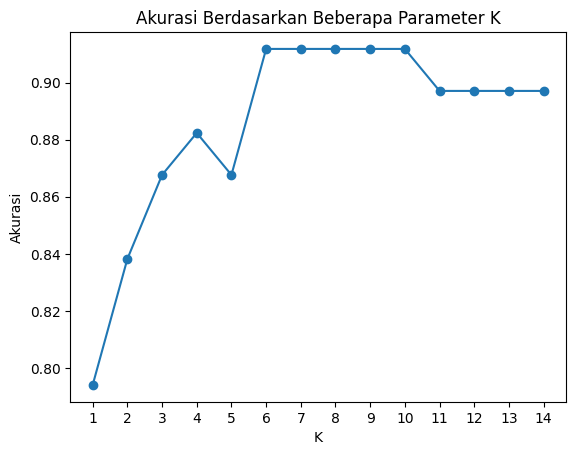

In [23]:
# Visualisasi
plt.plot(ks, accuracies, marker='o')
plt.xlabel('K')
plt.ylabel('Akurasi')
plt.title('Akurasi Berdasarkan Beberapa Parameter K')
plt.xticks(ks)
plt.show()

Dari model klasifikasi k-Nearest Neighbors yang telah dilatih sebelumnya, didapatkan hasil analisis sebagai berikut.
1.   Akurasi Model. Pada percobaan klasifikasi k-Nearest Neighbors yang dilakukan penentuan akurasi model ditentukan berdasarkan setting parameter k dengan rentang 1 hingga 14. Hasil pada percobaan tersebut menunjukkan Akurasi model yang sangat baik, yaitu berada pada skala 0.79 hingga 0.91 dimana akurasi terbaik saat k=6.
2.   Hasil Prediksi. Hasil prediksi yang didapat untuk X_test dengan k terbaik adalah Persebaran class terbanyak adalah "cp" yang berjumlah 35 instance dan tersedikit adalah "omL" yang berjumlah 1 instance.
1.   Visualisasi Grafik Akurasi. terlihat bahwa akurasi meningkat seiring dengan peningkatan nilai k hingga mencapai puncaknya pada k = 6 hingga k = 10, di mana akurasi mencapai 91.18%. Setelah k = 10, akurasi mulai menurun kembali saat nilai k terus bertambah. Hal ini menunjukkan bahwa untuk dataset dan kasus yang diberikan, k = 6 memberikan keseimbangan yang baik antara underfitting dan overfitting. Pada saat nilai k terlalu rendah, model cenderung overfitting karena terlalu sensitif terhadap noise dalam data, sedangkan saat nilai k terlalu tinggi, model menjadi terlalu sederhana dan cenderung underfitting.


#### Kesimpulan
Dari hasil analisis yang dilakukan terhadap model klasifikasi k-Nearest Neighbors (kNN) pada dataset ecoli, dapat disimpulkan beberapa hal.
1.  Akurasi model yang baik :
Akurasi pada Model k-NN menunjukkan performa yang baik dalam melakukan klasifikasi pada dataset yang diberikan. Dengan menggunakan k-NN dan menentukan parameter k yang sesuai, akurasi model dapat mencapai nilai yang tinggi, dalam kasus ini antara 0.79 hingga 0.91.
1.   Pentingnya Pemilihan k yang Tepat: Hasil menunjukkan bahwa pemilihan nilai k yang tepat memiliki dampak yang signifikan terhadap kinerja model. Nilai k yang tidak tepat dapat menyebabkan overfitting atau underfitting. Oleh karena itu, penting untuk melakukan eksperimen dan validasi untuk menentukan nilai k yang optimal.
2.   Variasi dalam Persebaran Kelas: Hasil prediksi menunjukkan variasi dalam persebaran kelas dari hasil prediksi. Hal ini menunjukkan bahwa model dapat mengidentifikasi kelas-kelas yang berbeda dengan baik, meskipun ada perbedaan dalam jumlah instance antara kelas-kelas tersebut.
3. Hasil Evaluasi menunjukan confusion matrix dimana label cp memiliki kesesuaian paling tinggi.
2.   Visualisasi Grafik Akurasi: Visualisasi grafik akurasi menunjukkan tren peningkatan akurasi seiring dengan peningkatan nilai k hingga mencapai puncaknya pada k = 6. Setelah itu, akurasi mulai menurun seiring dengan peningkatan nilai k. Hal ini menunjukkan bahwa penggunaan nilai k yang terlalu kecil atau terlalu besar dapat menyebabkan overfitting atau underfitting.